In [ ]:
import os
import zipfile

import torch
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM:", torch.cuda.get_device_properties(0).total_memory / 1e9, "GB")

zip_path = "/content/nalapro-project-final.zip"
extract_to = "/content/"

print("\nUnzipping...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

%cd /content/nalapro-project-final

print("\nDirectory contents:")
!ls -la

CUDA available: True
GPU: NVIDIA A100-SXM4-80GB
VRAM: 85.094825984 GB

Unzipping...
/content/nalapro-project-final

Directory contents:
total 60
drwxr-xr-x 10 root root 4096 May 20 23:29 .
drwxr-xr-x  1 root root 4096 May 20 23:29 ..
-rw-r--r--  1 root root 2818 May 20 23:29 config.py
drwxr-xr-x  2 root root 4096 May 20 23:29 docs
-rw-r--r--  1 root root  363 May 20 23:29 .gitignore
drwxr-xr-x  2 root root 4096 May 20 23:29 .ipynb_checkpoints
drwxr-xr-x  2 root root 4096 May 20 23:29 notebooks
drwxr-xr-x  4 root root 4096 May 20 23:29 outputs
drwxr-xr-x  2 root root 4096 May 20 23:29 __pycache__
-rw-r--r--  1 root root 3808 May 20 23:29 README.md
drwxr-xr-x  2 root root 4096 May 20 23:29 report
-rw-r--r--  1 root root  503 May 20 23:29 requirements.txt
-rw-r--r--  1 root root 2056 May 20 23:29 run_all.py
drwxr-xr-x  8 root root 4096 May 20 23:29 src
drwxr-xr-x  9 root root 4096 May 20 23:29 wandb


In [ ]:
!pip install -q -r requirements.txt
!pip install -q bitsandbytes>=0.43.0 accelerate>=0.30.0
print("\n✅ Dependencies installed")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 24.2 MB/s eta 0:00:00

✅ Dependencies installed


In [ ]:
import os
os.environ["WANDB_API_KEY"] = "hehe"

import wandb
wandb.login()
print("\n✅ W&B logged in")

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: nilabhpandey7 (nilabhpandey7-hslu) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin



✅ W&B logged in


In [ ]:
from huggingface_hub import login
login(token="hihi", add_to_git_credential=False)
print("\n✅ Hugging Face logged in")


✅ Hugging Face logged in


In [ ]:
import re

with open('config.py', 'r') as f:
    content = f.read()

content = re.sub(r'BERT_BATCH_SIZE = \\d+', 'BERT_BATCH_SIZE = 32', content)
content = re.sub(r'BERT_EPOCHS = \\d+', 'BERT_EPOCHS = 3', content)
content = re.sub(r'BERT_MAX_LEN = \\d+', 'BERT_MAX_LEN = 128', content)
content = re.sub(r'MLM_EPOCHS = \\d+', 'MLM_EPOCHS = 3', content)
content = re.sub(r'MLM_BATCH_SIZE = \\d+', 'MLM_BATCH_SIZE = 32', content)

with open('config.py', 'w') as f:
    f.write(content)

print("Updated config values:")
!grep -E "BERT_|MLM_" config.py
print("\n✅ Config updated for A100 (Task 2 ablation: max_len=128, batch=32, epochs=3)")

Updated config values:
BERT_MODEL = "bert-base-uncased"
BERT_LR = 2e-5
BERT_BATCH_SIZE = 4
BERT_EPOCHS = 1
BERT_WARMUP_RATIO = 0.1
BERT_MAX_LEN = 64
MLM_PROBABILITY = 0.15
MLM_EPOCHS = 1
MLM_LR = 5e-5
MLM_BATCH_SIZE = 4

✅ Config updated for A100 (Task 2 ablation: max_len=128, batch=32, epochs=3)


In [ ]:
!python -m src.task2.run


TASK 2 — Fine-tune bert-base-uncased
Loaded 20 Newsgroups: train=9051, val=2263, test=7532, classes=20
config.json: 100% 570/570 [00:00<00:00, 2.03MB/s]
tokenizer_config.json: 100% 48.0/48.0 [00:00<00:00, 166kB/s]
vocab.txt: 232kB [00:00, 6.57MB/s]
tokenizer.json: 466kB [00:00, 41.1MB/s]
model.safetensors: 100% 440M/440M [00:02<00:00, 209MB/s]
Loading weights: 100% 199/199 [00:00<00:00, 884.20it/s, Materializing param=bert.pooler.dense.weight]
BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relat

In [ ]:
import re
with open('config.py', 'r') as f:
    content = f.read()
content = re.sub(r'BERT_BATCH_SIZE = \\d+', 'BERT_BATCH_SIZE = 32', content)
content = re.sub(r'BERT_EPOCHS = \\d+', 'BERT_EPOCHS = 4', content)
content = re.sub(r'BERT_MAX_LEN = \\d+', 'BERT_MAX_LEN = 256', content)
content = re.sub(r'MLM_BATCH_SIZE = \\d+', 'MLM_BATCH_SIZE = 32', content)
with open('config.py', 'w') as f:
    f.write(content)
!grep -E "BERT_|MLM_" config.py
print("\n✅ A100 Task 2 BEST — max_len=256, epochs=4, batch=32")

BERT_MODEL = "bert-base-uncased"
BERT_LR = 2e-5
BERT_BATCH_SIZE = 4
BERT_EPOCHS = 1
BERT_WARMUP_RATIO = 0.1
BERT_MAX_LEN = 64
MLM_PROBABILITY = 0.15
MLM_EPOCHS = 1
MLM_LR = 5e-5
MLM_BATCH_SIZE = 4

✅ A100 Task 2 BEST — max_len=256, epochs=4, batch=32


In [ ]:
!python -m src.task2.run


TASK 2 — Fine-tune bert-base-uncased
Loaded 20 Newsgroups: train=9051, val=2263, test=7532, classes=20
Loading weights: 100% 199/199 [00:00<00:00, 1363.38it/s, Materializing param=bert.pooler.dense.weight]
BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architec

In [ ]:
import re
with open('config.py', 'r') as f:
    content = f.read()
content = re.sub(r'BERT_BATCH_SIZE = \\d+', 'BERT_BATCH_SIZE = 32', content)
content = re.sub(r'BERT_EPOCHS = \\d+', 'BERT_EPOCHS = 3', content)
content = re.sub(r'BERT_MAX_LEN = \\d+', 'BERT_MAX_LEN = 256', content)
content = re.sub(r'MLM_EPOCHS = \\d+', 'MLM_EPOCHS = 3', content)
content = re.sub(r'MLM_BATCH_SIZE = \\d+', 'MLM_BATCH_SIZE = 32', content)
with open('config.py', 'w') as f:
    f.write(content)
!grep -E "BERT_|MLM_" config.py
print("\n✅ A100 Task 3 — MLM 3 epochs (batch 32), classify 3 epochs (batch 32), max_len 256")

BERT_MODEL = "bert-base-uncased"
BERT_LR = 2e-5
BERT_BATCH_SIZE = 4
BERT_EPOCHS = 1
BERT_WARMUP_RATIO = 0.1
BERT_MAX_LEN = 64
MLM_PROBABILITY = 0.15
MLM_EPOCHS = 1
MLM_LR = 5e-5
MLM_BATCH_SIZE = 4

✅ A100 Task 3 — MLM 3 epochs (batch 32), classify 3 epochs (batch 32), max_len 256


In [ ]:
!python -m src.task3.run

Loaded 20 Newsgroups: train=9051, val=2263, test=7532, classes=20

TASK 3 Stage 1 — MLM pretraining
  MLM pretraining on 17886 documents
Loading weights: 100% 202/202 [00:00<00:00, 1263.82it/s, Materializing param=cls.predictions.transform.dense.weight]
BertForMaskedLM LOAD REPORT from: bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
cls.seq_relationship.bias   | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: nilabhpandey7 (nilabhpandey7-hslu) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use

In [ ]:
import re
with open('config.py', 'r') as f:
    content = f.read()

content = re.sub(r'LLAMA_NUM_FEW_SHOT = \d+', 'LLAMA_NUM_FEW_SHOT = 3', content)
content = re.sub(r'LLAMA_EVAL_SAMPLES = \d+', 'LLAMA_EVAL_SAMPLES = 200', content)
content = re.sub(r'LLAMA_MAX_NEW_TOKENS = \d+', 'LLAMA_MAX_NEW_TOKENS = 30', content)

with open('config.py', 'w') as f:
    f.write(content)

!grep -E "LLAMA_" config.py
print("\n✅ Task 4 config ready")

LLAMA_MODEL = "meta-llama/Meta-Llama-3-8B-Instruct"
LLAMA_MAX_NEW_TOKENS = 30
LLAMA_TEMPERATURE = 0.1
LLAMA_NUM_FEW_SHOT = 3        # Examples in few-shot prompt
LLAMA_EVAL_SAMPLES = 200      # How many test docs to evaluate (LLM is slow)
LLAMA_USE_4BIT = True         # 4-bit quantization to fit on small GPUs

✅ Task 4 config ready


In [ ]:
import torch
import gc
gc.collect()
torch.cuda.empty_cache()

print(f"GPU memory before Llama load:")
print(f"  Allocated: {torch.cuda.memory_allocated() / 1e9:.2f} GB")
print(f"  Reserved:  {torch.cuda.memory_reserved() / 1e9:.2f} GB")
print(f"  Total VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

GPU memory before Llama load:
  Allocated: 0.00 GB
  Reserved:  0.00 GB
  Total VRAM: 85.09 GB


In [ ]:
from huggingface_hub import HfApi, whoami
print("Logged in as:", whoami()['name'])

api = HfApi()
try:
    info = api.model_info("meta-llama/Meta-Llama-3-8B-Instruct")
    print("✅ Llama-3 access confirmed")
    print(f"   Model: {info.modelId}")
except Exception as e:
    print(f"❌ Access denied: {e}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Logged in as: nilabhpandey
✅ Llama-3 access confirmed
   Model: meta-llama/Meta-Llama-3-8B-Instruct


In [ ]:
!python -m src.task4.run


TASK 4 — Llama-3 zero-shot / few-shot (meta-llama/Meta-Llama-3-8B-Instruct)
Loaded 20 Newsgroups: train=9051, val=2263, test=7532, classes=20
  loading meta-llama/Meta-Llama-3-8B-Instruct...
  using 4-bit quantization (bitsandbytes)
config.json: 100% 654/654 [00:00<00:00, 1.56MB/s]
tokenizer_config.json: 51.0kB [00:00, 73.1MB/s]
tokenizer.json: 9.09MB [00:00, 21.7MB/s]
special_tokens_map.json: 100% 73.0/73.0 [00:00<00:00, 335kB/s]
model.safetensors.index.json: 23.9kB [00:00, 49.7MB/s]
Fetching 4 files: 100% 4/4 [00:44<00:00, 11.06s/it]
Download complete: 100% 16.1G/16.1G [00:44<00:00, 363MB/s]
Loading weights: 100% 291/291 [00:04<00:00, 62.78it/s, Materializing param=model.norm.weight] 
generation_config.json: 100% 187/187 [00:00<00:00, 908kB/s]
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: nilabhpandey7 (nilabhpandey7-hslu) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using

Loading 20 Newsgroups...


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Loaded Llama-3 on cuda:0 | GPU used 5.7 GB


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


Llama zero_shot: 100%|██████████| 200/200 [01:25<00:00,  2.35it/s]



[zero_shot]
  Accuracy: 0.5050
  F1:       0.4578
  Unparseable: 0/200 (0.0%)
                          precision    recall  f1-score   support

             alt.atheism       0.50      0.12      0.20         8
           comp.graphics       0.19      0.40      0.26        10
 comp.os.ms-windows.misc       1.00      0.10      0.18        10
comp.sys.ibm.pc.hardware       0.36      0.92      0.52        13
   comp.sys.mac.hardware       0.86      0.50      0.63        12
          comp.windows.x       0.00      0.00      0.00         6
            misc.forsale       0.71      0.45      0.56        11
               rec.autos       0.30      0.50      0.38         6
         rec.motorcycles       0.67      0.40      0.50         5
      rec.sport.baseball       1.00      0.73      0.84        11
        rec.sport.hockey       1.00      0.82      0.90        11
               sci.crypt       0.44      0.44      0.44         9
         sci.electronics       0.00      0.00      0.00       

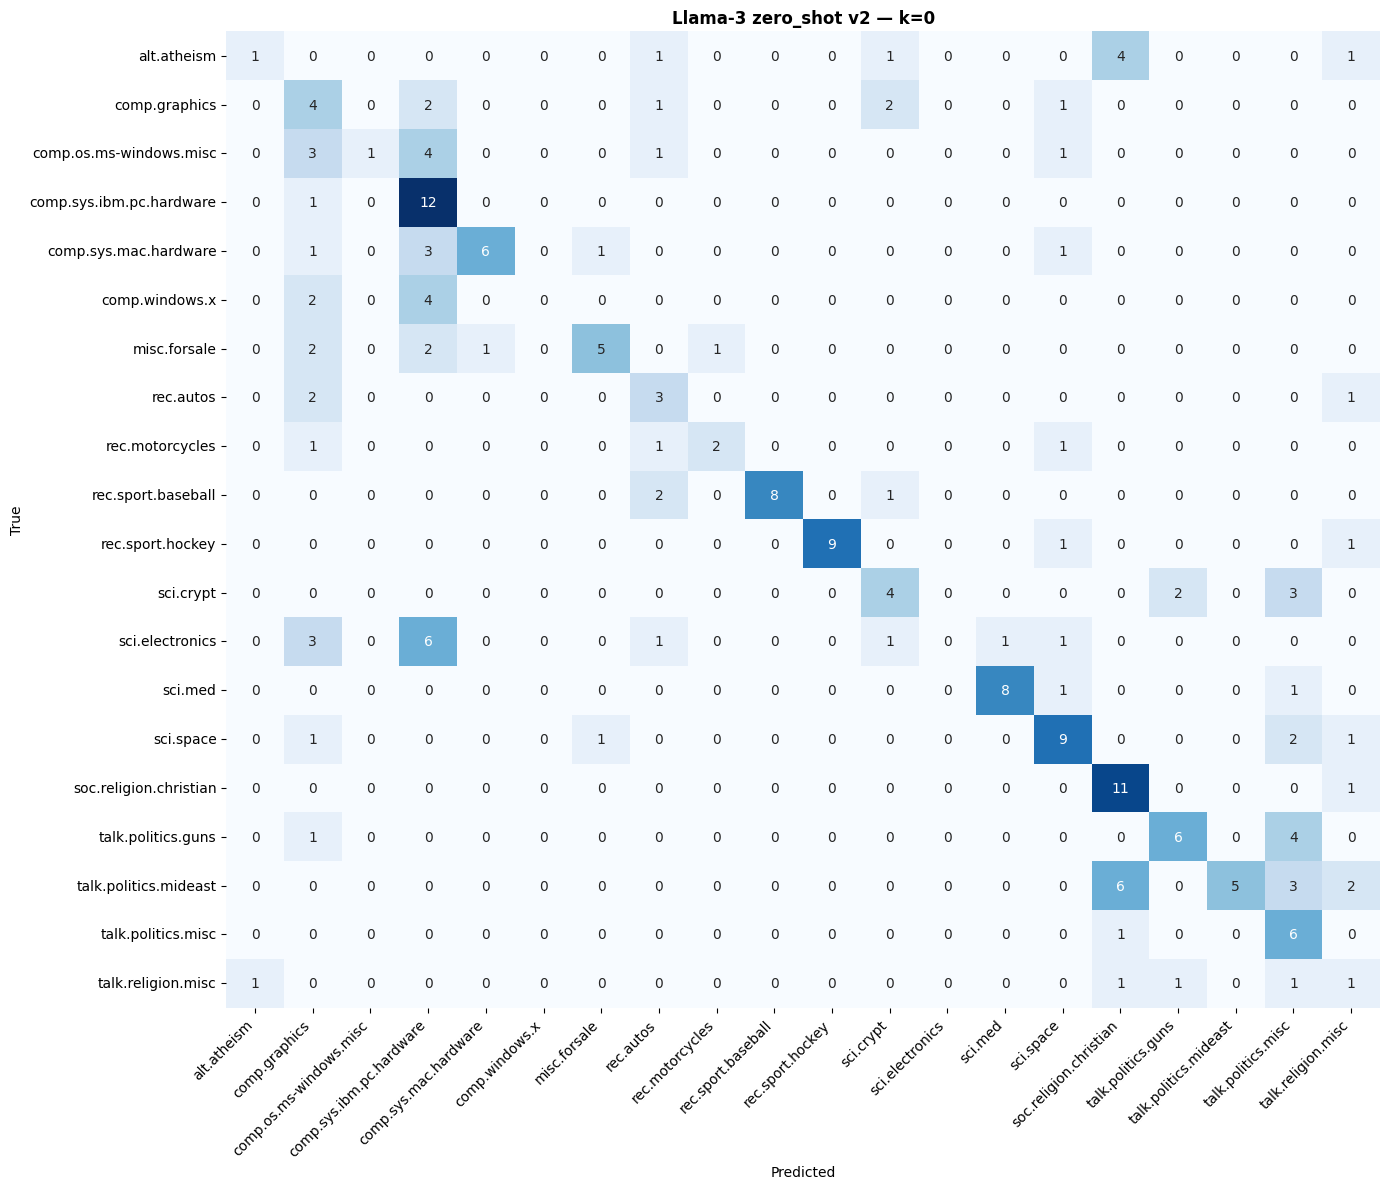

  Saved: outputs/plots/task4_zero_shot_cm_v2.png


Llama few_shot: 100%|██████████| 200/200 [01:31<00:00,  2.19it/s]



[few_shot]
  Accuracy: 0.4600
  F1:       0.4066
  Unparseable: 2/200 (1.0%)
                          precision    recall  f1-score   support

             alt.atheism       1.00      0.25      0.40         8
           comp.graphics       0.38      0.50      0.43        10
 comp.os.ms-windows.misc       0.00      0.00      0.00        10
comp.sys.ibm.pc.hardware       0.35      0.92      0.51        13
   comp.sys.mac.hardware       0.71      0.45      0.56        11
          comp.windows.x       0.00      0.00      0.00         5
            misc.forsale       0.50      0.64      0.56        11
               rec.autos       0.40      0.33      0.36         6
         rec.motorcycles       0.50      0.20      0.29         5
      rec.sport.baseball       1.00      0.64      0.78        11
        rec.sport.hockey       1.00      0.82      0.90        11
               sci.crypt       0.60      0.33      0.43         9
         sci.electronics       0.43      0.23      0.30        

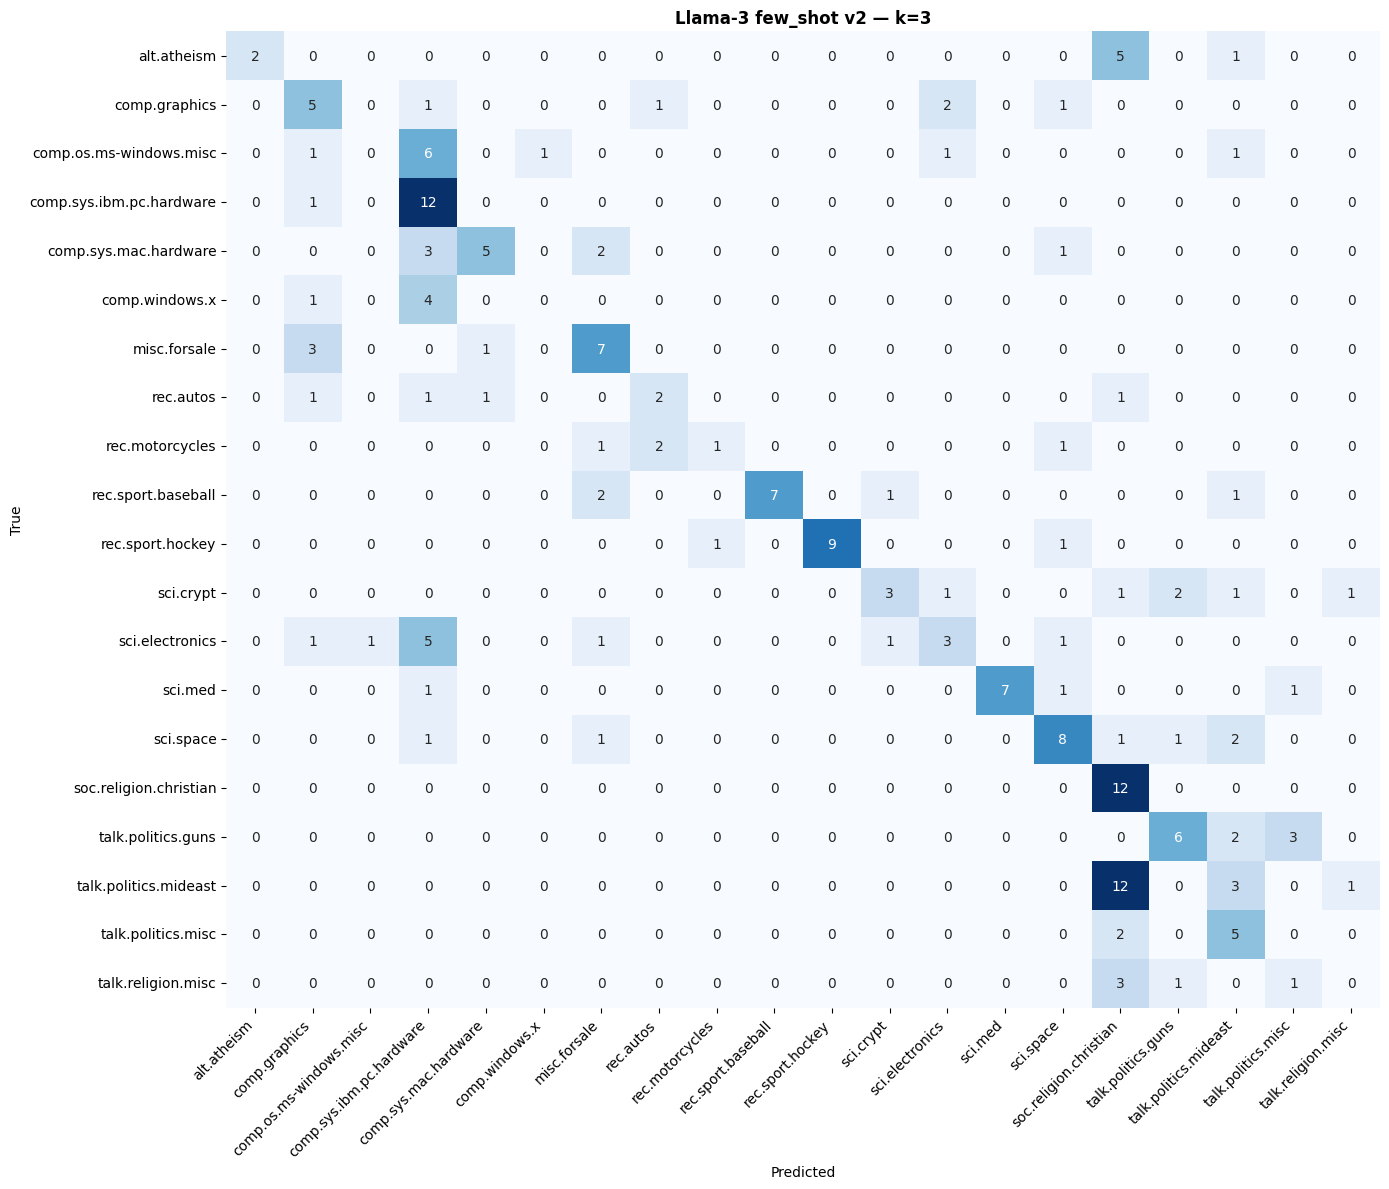

  Saved: outputs/plots/task4_few_shot_cm_v2.png


fs_accuracy_v2,▁
fs_f1_v2,▁
fs_unparseable_v2,▁
zs_accuracy_v2,▁
zs_f1_v2,▁
zs_unparseable_v2,▁
fs_accuracy_v2,0.46
fs_f1_v2,0.40656
fs_unparseable_v2,2
zs_accuracy_v2,0.505
zs_f1_v2,0.45777



TASK 4 v2 — Summary
Zero-shot v2: acc=0.5050  F1=0.4578  unparseable=0/200
Few-shot v2:  acc=0.4600  F1=0.4066  unparseable=2/200


In [ ]:
import json
import random
import torch
from collections import Counter
from tqdm import tqdm
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from sklearn.datasets import fetch_20newsgroups
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                              classification_report, confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns
import wandb
import numpy as np

import config

CATEGORIES = [
    'alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc',
    'comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware',
    'comp.windows.x', 'misc.forsale', 'rec.autos', 'rec.motorcycles',
    'rec.sport.baseball', 'rec.sport.hockey', 'sci.crypt',
    'sci.electronics', 'sci.med', 'sci.space',
    'soc.religion.christian', 'talk.politics.guns',
    'talk.politics.mideast', 'talk.politics.misc', 'talk.religion.misc'
]

print("Loading 20 Newsgroups...")
train = fetch_20newsgroups(subset='train', remove=('headers', 'footers', 'quotes'))
test  = fetch_20newsgroups(subset='test',  remove=('headers', 'footers', 'quotes'))

rng = random.Random(config.RANDOM_SEED)
indices = rng.sample(range(len(test.data)), config.LLAMA_EVAL_SAMPLES)
eval_texts  = [test.data[i]  for i in indices]
eval_labels = [test.target[i] for i in indices]

import os
os.makedirs('outputs/plots', exist_ok=True)
quant = BitsAndBytesConfig(
    load_in_4bit=True, bnb_4bit_quant_type='nf4',
    bnb_4bit_compute_dtype=torch.bfloat16, bnb_4bit_use_double_quant=True,
)
tokenizer = AutoTokenizer.from_pretrained(config.LLAMA_MODEL)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
model = AutoModelForCausalLM.from_pretrained(
    config.LLAMA_MODEL, device_map='auto',
    quantization_config=quant, torch_dtype=torch.bfloat16,
)
model.eval()
print(f"Loaded Llama-3 on {model.device} | GPU used {torch.cuda.memory_allocated()/1e9:.1f} GB")

SYSTEM = (
    "You are an expert text classifier for the 20 Newsgroups dataset. "
    "Given a post, output EXACTLY one category name from this list — and nothing else. "
    "Do not explain. Do not add any words. Just output the category name.\n\n"
    "Categories:\n" + "\n".join(f"- {c}" for c in CATEGORIES)
)

def build_user_message(post_text, examples=None):
    msg = ""
    if examples:
        msg += f"Here are {len(examples)} example classifications:\n\n"
        for ex_text, ex_label in examples:
            msg += f'POST: """{ex_text[:400]}"""\nCATEGORY: {ex_label}\n\n'
        msg += "---\nNow classify this post:\n\n"
    msg += f'POST: """{post_text[:1500]}"""\nCATEGORY:'
    return msg

def classify(post_text, examples=None):
    messages = [
        {"role": "system", "content": SYSTEM},
        {"role": "user", "content": build_user_message(post_text, examples)},
    ]
    prompt_text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )
    inputs = tokenizer(prompt_text, return_tensors='pt', truncation=True,
                       max_length=4096).to(model.device)

    with torch.no_grad():
        out = model.generate(
            input_ids=inputs['input_ids'],
            attention_mask=inputs['attention_mask'],
            max_new_tokens=20,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=[tokenizer.eos_token_id,
                          tokenizer.convert_tokens_to_ids("<|eot_id|>")],
        )
    response = tokenizer.decode(out[0, inputs['input_ids'].shape[1]:],
                                 skip_special_tokens=True).strip()
    return response

def parse_to_category(text):
    text_low = text.lower().strip()

    for i, c in enumerate(CATEGORIES):
        if c.lower() == text_low or c.lower() in text_low.split('\n')[0]:
            return i

    keyword_map = {
        'atheism': 0, 'graphics': 1, 'ms-windows': 2, 'windows.misc': 2,
        'ibm.pc': 3, 'pc.hardware': 3, 'mac': 4, 'macintosh': 4,
        'windows.x': 5, 'x11': 5, 'forsale': 6, 'for sale': 6, 'sale': 6,
        'autos': 7, 'cars': 7, 'automobile': 7,
        'motorcycle': 8, 'bike': 8,
        'baseball': 9, 'hockey': 10, 'crypt': 11, 'encryption': 11,
        'electronics': 12, 'sci.med': 13, 'medicine': 13, 'medical': 13,
        'space': 14, 'nasa': 14, 'astron': 14,
        'christian': 15, 'religion.christ': 15,
        'guns': 16, 'firearm': 16, 'mideast': 17, 'middle east': 17,
        'politics.misc': 18, 'religion.misc': 19, 'religion misc': 19,
    }
    for kw, idx in keyword_map.items():
        if kw in text_low:
            return idx
    return None

def pick_diverse_examples(train_texts, train_labels, n_examples, seed=42):
    rng = random.Random(seed)
    by_cat = {}
    for t, y in zip(train_texts, train_labels):
        if 100 < len(t) < 1500:
            by_cat.setdefault(y, []).append(t)
    chosen_cats = rng.sample(list(by_cat.keys()), n_examples)
    return [(rng.choice(by_cat[c]), CATEGORIES[c]) for c in chosen_cats]

def evaluate(examples, name):
    preds = []
    unparseable = 0
    for txt in tqdm(eval_texts, desc=f'Llama {name}'):
        resp = classify(txt, examples=examples)
        cat = parse_to_category(resp)
        if cat is None:
            unparseable += 1
            preds.append(-1)
        else:
            preds.append(cat)

    y_true = np.array(eval_labels)
    y_pred = np.array(preds)
    acc = accuracy_score(y_true, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro', zero_division=0,
        labels=list(range(20)),
    )
    print(f"\n[{name}]")
    print(f"  Accuracy: {acc:.4f}")
    print(f"  F1:       {f1:.4f}")
    print(f"  Unparseable: {unparseable}/{len(preds)} ({unparseable/len(preds)*100:.1f}%)")

    valid = y_pred >= 0
    print(classification_report(
        y_true[valid], y_pred[valid],
        target_names=CATEGORIES, zero_division=0, digits=2,
    ))

    cm = confusion_matrix(y_true[valid], y_pred[valid], labels=list(range(20)))
    plt.figure(figsize=(14, 12))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CATEGORIES, yticklabels=CATEGORIES, cbar=False)
    plt.title(f'Llama-3 {name} v2 — k={config.LLAMA_NUM_FEW_SHOT if examples else 0}',
              fontweight='bold')
    plt.xlabel('Predicted'); plt.ylabel('True')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    out = f'outputs/plots/task4_{name}_cm_v2.png'
    plt.savefig(out, dpi=120, bbox_inches='tight')
    plt.show()
    print(f"  Saved: {out}")
    return acc, f1, unparseable

wandb.init(project=config.WANDB_PROJECT, name='task4_llama_v2 collab',
           config={'fix': 'chat_template + diverse_few_shot'}, reinit=True)

# Zero-shot
zs_acc, zs_f1, zs_unp = evaluate(examples=None, name='zero_shot')

# Few-shot
fs_examples = pick_diverse_examples(train.data, train.target,
                                      n_examples=config.LLAMA_NUM_FEW_SHOT)
fs_acc, fs_f1, fs_unp = evaluate(examples=fs_examples, name='few_shot')

wandb.log({
    'zs_accuracy_v2': zs_acc, 'zs_f1_v2': zs_f1, 'zs_unparseable_v2': zs_unp,
    'fs_accuracy_v2': fs_acc, 'fs_f1_v2': fs_f1, 'fs_unparseable_v2': fs_unp,
})
wandb.finish()

print("\n" + "="*60)
print("TASK 4 v2 — Summary")
print("="*60)
print(f"Zero-shot v2: acc={zs_acc:.4f}  F1={zs_f1:.4f}  unparseable={zs_unp}/200")
print(f"Few-shot v2:  acc={fs_acc:.4f}  F1={fs_f1:.4f}  unparseable={fs_unp}/200")

In [ ]:
!pip install -q -U peft bitsandbytes accelerate
print("✅ PEFT + bitsandbytes installed")

✅ PEFT + bitsandbytes installed


In [ ]:
import gc, torch
for _v in ['model', 'tokenizer']:
    if _v in globals():
        del globals()[_v]
gc.collect(); torch.cuda.empty_cache()
print(f"GPU free after clear: {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated())/1e9:.1f} GB")

from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
import config

MODEL = config.LLAMA_MODEL
bnb = BitsAndBytesConfig(
    load_in_4bit=True, bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16, bnb_4bit_use_double_quant=True,
)
tokenizer = AutoTokenizer.from_pretrained(MODEL)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

model = AutoModelForCausalLM.from_pretrained(
    MODEL, device_map="auto", quantization_config=bnb, torch_dtype=torch.bfloat16,
)
model.config.use_cache = False
model = prepare_model_for_kbit_training(model, use_gradient_checkpointing=False)

lora = LoraConfig(
    r=16, lora_alpha=32, lora_dropout=0.05, bias="none", task_type="CAUSAL_LM",
    target_modules=["q_proj","k_proj","v_proj","o_proj","gate_proj","up_proj","down_proj"],
)
model = get_peft_model(model, lora)
model.print_trainable_parameters()
print(f"GPU used after load: {torch.cuda.memory_allocated()/1e9:.1f} GB / 40 GB")
print("✅ Llama-3 + LoRA ready for QLoRA (A100)")

GPU free after clear: 85.1 GB


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

trainable params: 41,943,040 || all params: 8,072,204,288 || trainable%: 0.5196
GPU used after load: 8.0 GB / 40 GB
✅ Llama-3 + LoRA ready for QLoRA (A100)


In [ ]:
import random
import numpy as np
from sklearn.datasets import fetch_20newsgroups
from datasets import Dataset

CATEGORIES = [
    'alt.atheism','comp.graphics','comp.os.ms-windows.misc','comp.sys.ibm.pc.hardware',
    'comp.sys.mac.hardware','comp.windows.x','misc.forsale','rec.autos','rec.motorcycles',
    'rec.sport.baseball','rec.sport.hockey','sci.crypt','sci.electronics','sci.med',
    'sci.space','soc.religion.christian','talk.politics.guns','talk.politics.mideast',
    'talk.politics.misc','talk.religion.misc'
]

train_raw = fetch_20newsgroups(subset='train', remove=('headers','footers','quotes'))

rng = random.Random(config.RANDOM_SEED)
by_cls = {}
for txt, y in zip(train_raw.data, train_raw.target):
    if 50 < len(txt) < 3000:
        by_cls.setdefault(y, []).append(txt)
PER_CLASS = 150
sub_texts, sub_labels = [], []
for y, docs in by_cls.items():
    picks = rng.sample(docs, min(PER_CLASS, len(docs)))
    sub_texts += picks; sub_labels += [y]*len(picks)
print(f"Training subset: {len(sub_texts)} docs across {len(set(sub_labels))} classes")

SYSTEM = "Classify the newsgroup post into its category. Reply with only the category name."
MAX_LEN = 256

def build_example(text, label_idx):
    messages = [
        {"role":"system","content":SYSTEM},
        {"role":"user","content":f'POST: """{text[:1000]}"""\nCATEGORY:'},
    ]
    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    answer = " " + CATEGORIES[label_idx] + tokenizer.eos_token
    prompt_ids = tokenizer(prompt, add_special_tokens=False)["input_ids"]
    answer_ids = tokenizer(answer, add_special_tokens=False)["input_ids"]
    max_prompt = MAX_LEN - len(answer_ids)
    if len(prompt_ids) > max_prompt:
        prompt_ids = prompt_ids[:max_prompt]
    input_ids = prompt_ids + answer_ids
    labels    = [-100]*len(prompt_ids) + answer_ids
    attn      = [1]*len(input_ids)
    pad = MAX_LEN - len(input_ids)
    input_ids += [tokenizer.pad_token_id]*pad
    labels    += [-100]*pad
    attn      += [0]*pad
    return {"input_ids":input_ids, "attention_mask":attn, "labels":labels}

train_ds = Dataset.from_list([build_example(t,y) for t,y in zip(sub_texts, sub_labels)])

_real = [l for l in train_ds[0]['labels'] if l != -100]
print(f"✅ {len(train_ds)} examples (max_len={MAX_LEN}). First example answer tokens: {len(_real)} (must be > 0)")
print("   Decoded answer:", tokenizer.decode(_real))

Training subset: 3000 docs across 20 classes
✅ 3000 examples (max_len=256). First example answer tokens: 4 (must be > 0)
   Decoded answer:  rec.autos<|eot_id|>


In [ ]:
from transformers import Trainer, TrainingArguments, DataCollatorForSeq2Seq
import wandb, time

wandb.init(project=config.WANDB_PROJECT, name="task4_llama_qlora", reinit=True,
           config={"method":"QLoRA","r":16,"per_class":150,"max_len":MAX_LEN,"epochs":2,"gpu":"A100"})

args = TrainingArguments(
    output_dir="outputs/llama_qlora",
    num_train_epochs=2,
    per_device_train_batch_size=8,
    gradient_accumulation_steps=2,
    gradient_checkpointing=False,
    optim="paged_adamw_8bit",
    learning_rate=2e-4,
    weight_decay=0.001,
    warmup_ratio=0.03,
    lr_scheduler_type="cosine",
    max_grad_norm=0.3,
    bf16=True,
    logging_steps=10,
    save_strategy="no",
    report_to="wandb",
)

trainer = Trainer(model=model, args=args, train_dataset=train_ds,
                  data_collator=DataCollatorForSeq2Seq(tokenizer, padding=False))

t0 = time.time()
trainer.train()
print(f"✅ QLoRA trained in {(time.time()-t0)/60:.1f} min")

model.save_pretrained("outputs/llama_qlora_adapter")
tokenizer.save_pretrained("outputs/llama_qlora_adapter")
print("✅ Adapter saved to outputs/llama_qlora_adapter")
wandb.finish()



warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Step,Training Loss
10,2.884831
20,0.711825
30,0.355703
40,0.372319
50,0.315855
60,0.278927
70,0.351311
80,0.218616
90,0.237397
100,0.252213


✅ QLoRA trained in 8.7 min
✅ Adapter saved to outputs/llama_qlora_adapter


train/epoch,▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇████
train/global_step,▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇████
train/grad_norm,█▆▃▄▄▄▄▄▃▄▃▃▄▃▃▂▃▂▄▁▃▃▂▂▃▃▂▂▂▂▂▂▂▂▁▂▂
train/learning_rate,▆██████▇▇▇▇▇▆▆▆▆▅▅▅▄▄▄▃▃▃▃▂▂▂▂▂▁▁▁▁▁▁
train/loss,█▃▂▂▂▂▂▁▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
total_flos,6.9551932833792e+16
train/epoch,2
train/global_step,376
train/grad_norm,0.94427
train/learning_rate,0.0
train/loss,0.08683


QLoRA eval: 100%|██████████| 200/200 [02:48<00:00,  1.19it/s]



QLoRA fine-tuned — accuracy 0.7800  macro-F1 0.7465  unparseable 0/200
                          precision    recall  f1-score   support

             alt.atheism       0.43      0.38      0.40         8
           comp.graphics       0.73      0.80      0.76        10
 comp.os.ms-windows.misc       0.75      0.60      0.67        10
comp.sys.ibm.pc.hardware       0.93      1.00      0.96        13
   comp.sys.mac.hardware       0.89      0.67      0.76        12
          comp.windows.x       1.00      0.83      0.91         6
            misc.forsale       0.83      0.91      0.87        11
               rec.autos       1.00      0.83      0.91         6
         rec.motorcycles       0.75      0.60      0.67         5
      rec.sport.baseball       1.00      0.91      0.95        11
        rec.sport.hockey       0.69      1.00      0.81        11
               sci.crypt       1.00      0.78      0.88         9
         sci.electronics       0.75      0.69      0.72        13
   

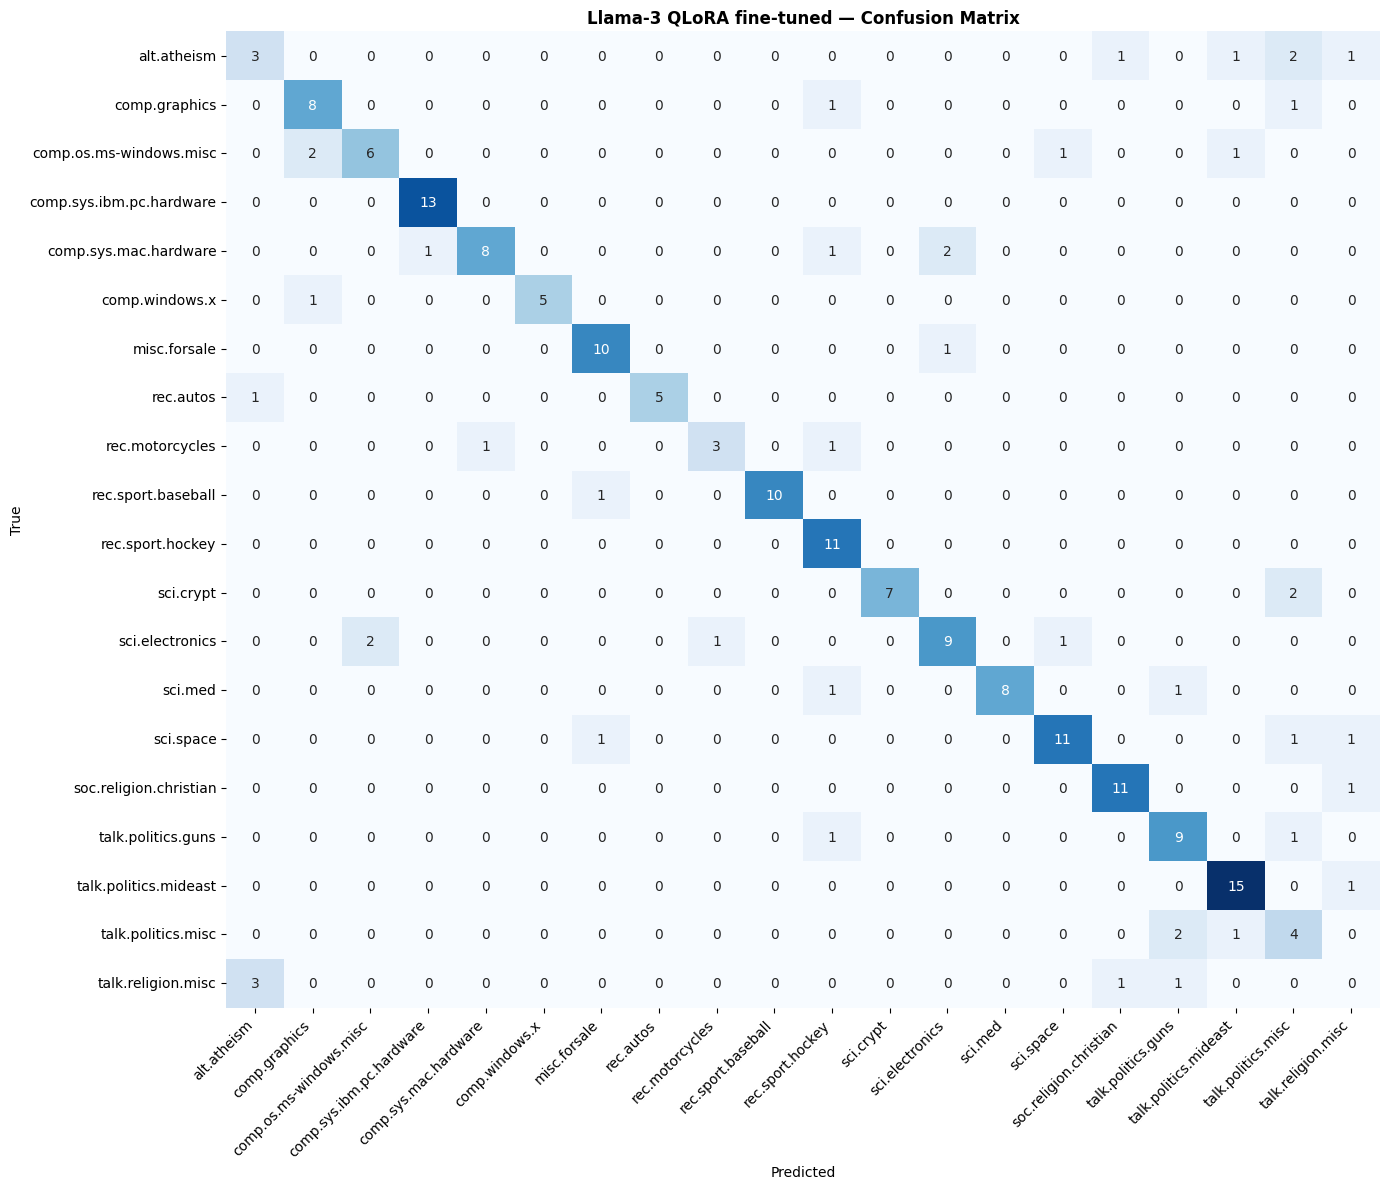

✅ Saved outputs/plots/task4_qlora_cm.png


In [ ]:
import os; os.makedirs('outputs/plots', exist_ok=True)
import numpy as np
from tqdm import tqdm
from sklearn.datasets import fetch_20newsgroups
from sklearn.metrics import (accuracy_score, f1_score,
                              classification_report, confusion_matrix)
import matplotlib.pyplot as plt, seaborn as sns

test_raw = fetch_20newsgroups(subset='test', remove=('headers','footers','quotes'))
rng = random.Random(config.RANDOM_SEED)
idx = rng.sample(range(len(test_raw.data)), config.LLAMA_EVAL_SAMPLES)
eval_texts  = [test_raw.data[i]  for i in idx]
eval_labels = [test_raw.target[i] for i in idx]

model.config.use_cache = True
model.eval()

def classify_ft(text):
    messages = [
        {"role":"system","content":SYSTEM},
        {"role":"user","content":f'POST: """{text[:1200]}"""\nCATEGORY:'},
    ]
    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=1024).to(model.device)
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=15, do_sample=False,
                             pad_token_id=tokenizer.eos_token_id)
    return tokenizer.decode(out[0, inputs['input_ids'].shape[1]:], skip_special_tokens=True).strip()

def parse(text):
    t = text.lower()
    for i,c in enumerate(CATEGORIES):
        if c.lower() in t: return i
    return -1

preds, unparse = [], 0
for txt in tqdm(eval_texts, desc="QLoRA eval"):
    c = parse(classify_ft(txt))
    if c == -1: unparse += 1
    preds.append(c)

y_true, y_pred = np.array(eval_labels), np.array(preds)
acc = accuracy_score(y_true, y_pred)
f1  = f1_score(y_true, y_pred, average='macro', labels=list(range(20)))
valid = y_pred >= 0
print(f"\nQLoRA fine-tuned — accuracy {acc:.4f}  macro-F1 {f1:.4f}  unparseable {unparse}/200")
print(classification_report(y_true[valid], y_pred[valid],
      target_names=CATEGORIES, zero_division=0, digits=2))

cm = confusion_matrix(y_true[valid], y_pred[valid], labels=list(range(20)))
plt.figure(figsize=(14,12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CATEGORIES, yticklabels=CATEGORIES, cbar=False)
plt.title('Llama-3 QLoRA fine-tuned — Confusion Matrix', fontweight='bold')
plt.xlabel('Predicted'); plt.ylabel('True'); plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('outputs/plots/task4_qlora_cm.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Saved outputs/plots/task4_qlora_cm.png")

In [ ]:
import shutil
from google.colab import files
shutil.make_archive('/content/nalapro_ALL_outputs', 'zip', 'outputs')
print("Zipped outputs/ ->", )
files.download('/content/nalapro_ALL_outputs.zip')
print("✅ Downloaded nalapro_ALL_outputs.zip — safe to disconnect")

Zipped outputs/ ->


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded nalapro_ALL_outputs.zip — safe to disconnect


Loading 20 Newsgroups for EDA...
Categories: 20
Train docs: 11314
Test docs:  7532


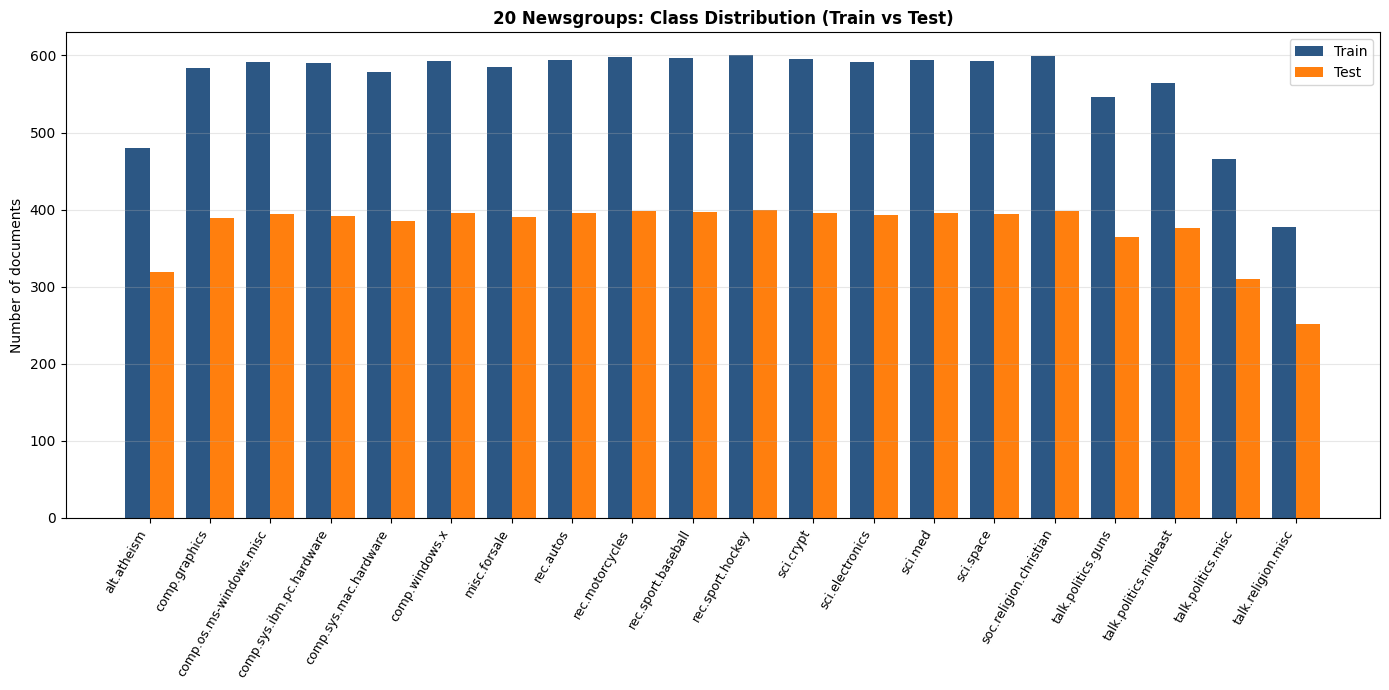

✅ Saved: eda_class_distribution.png


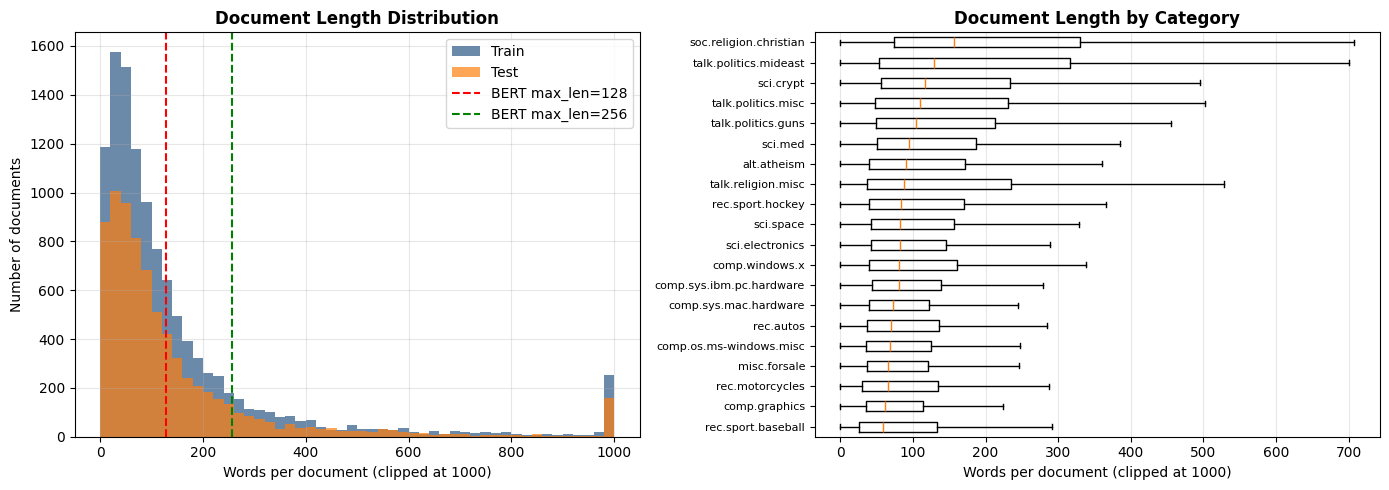

✅ Saved: eda_doc_length.png

Document length statistics:
  Mean:   186 words
  Median: 83 words
  90th %: 336 words
  Max:    11765 words
  >128 tokens:  33.8% of docs
  >256 tokens:  14.3% of docs


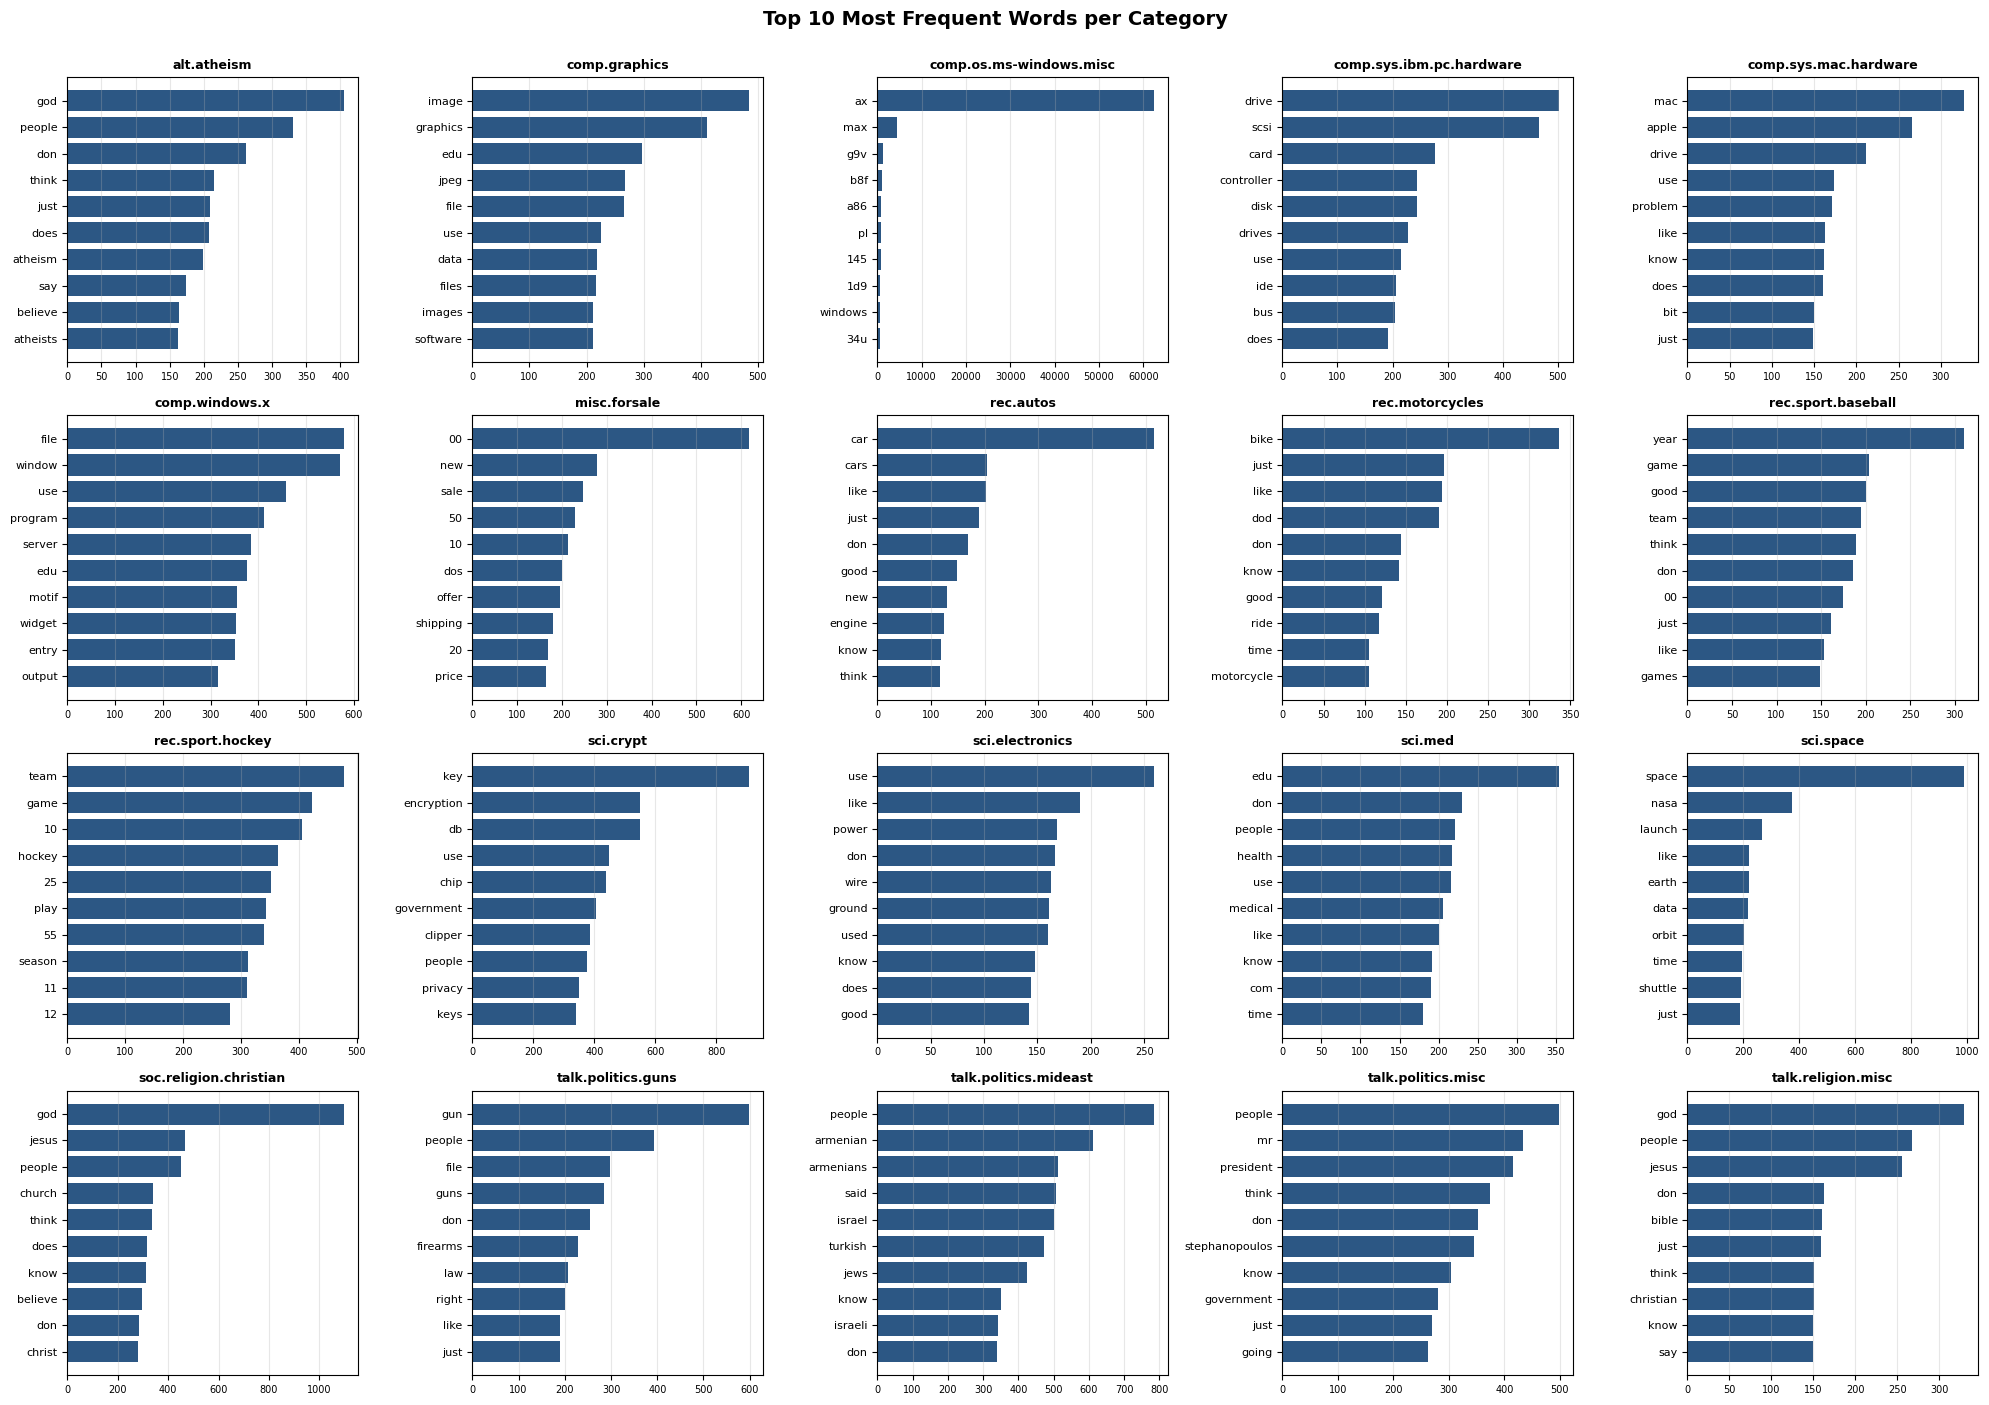

✅ Saved: eda_top_words_per_class.png

Vocabulary statistics (train set):
  Total tokens:     1,624,113
  Unique tokens:    46,733
  Tokens / doc avg: 144
  Hapax (1-count):  19,710 (42.2% of vocab)


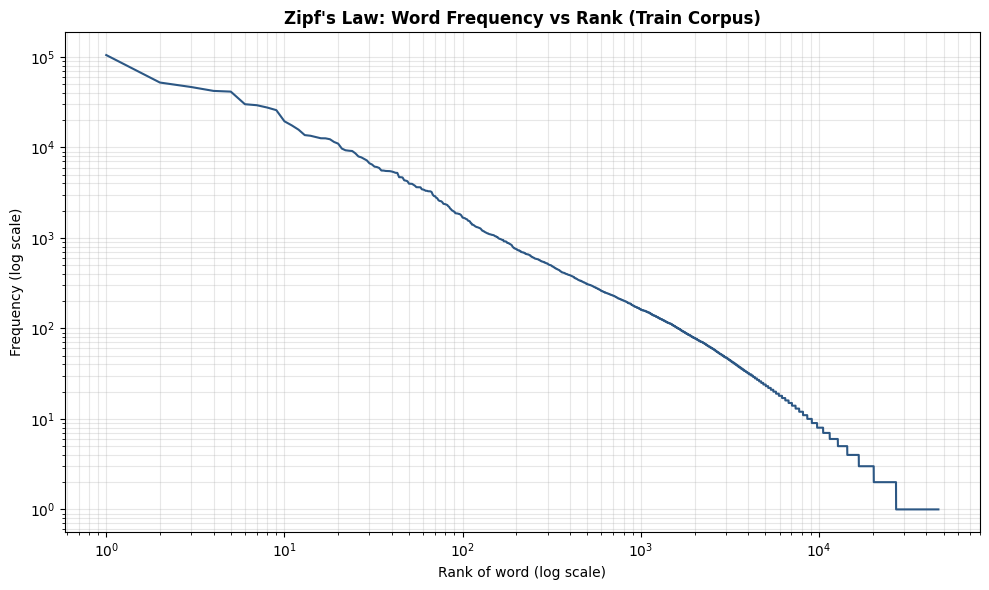

✅ Saved: eda_zipf.png


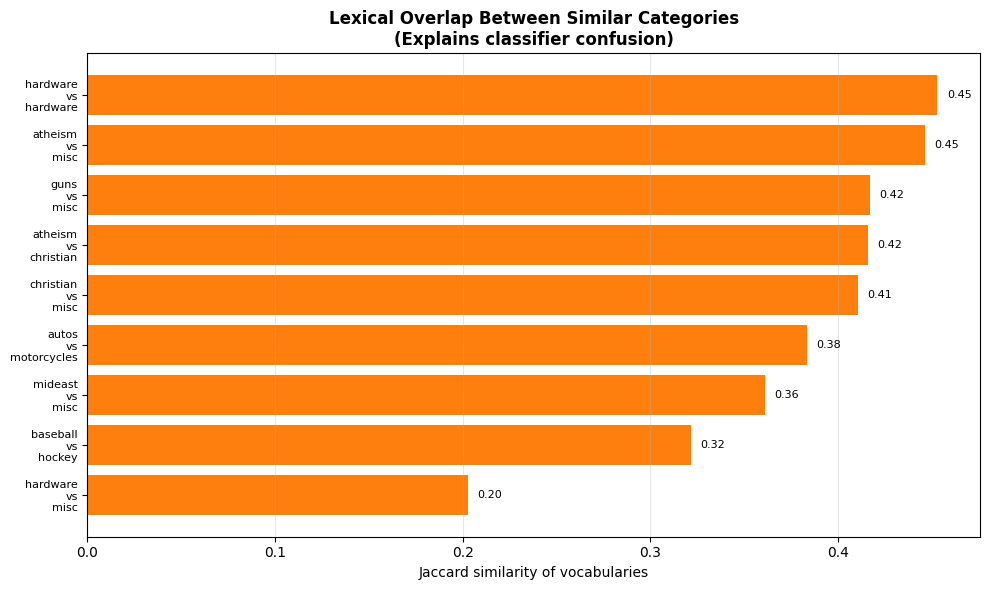

✅ Saved: eda_category_overlap.png

EDA COMPLETE — all plots saved to outputs/plots/


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer

os.makedirs('outputs/plots', exist_ok=True)

print("Loading 20 Newsgroups for EDA...")
train_raw = fetch_20newsgroups(subset='train', remove=('headers', 'footers', 'quotes'))
test_raw  = fetch_20newsgroups(subset='test',  remove=('headers', 'footers', 'quotes'))

CATEGORIES = train_raw.target_names
print(f"Categories: {len(CATEGORIES)}")
print(f"Train docs: {len(train_raw.data)}")
print(f"Test docs:  {len(test_raw.data)}")

train_counts = Counter(train_raw.target)
test_counts  = Counter(test_raw.target)

fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(CATEGORIES))
width = 0.4
ax.bar(x - width/2, [train_counts[i] for i in range(20)], width, label='Train', color='#2c5784')
ax.bar(x + width/2, [test_counts[i]  for i in range(20)], width, label='Test',  color='#ff7f0e')
ax.set_xticks(x)
ax.set_xticklabels(CATEGORIES, rotation=60, ha='right', fontsize=9)
ax.set_ylabel('Number of documents')
ax.set_title('20 Newsgroups: Class Distribution (Train vs Test)', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/plots/eda_class_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Saved: eda_class_distribution.png")

train_lengths = [len(doc.split()) for doc in train_raw.data]
test_lengths  = [len(doc.split()) for doc in test_raw.data]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(np.clip(train_lengths, 0, 1000), bins=50, alpha=0.7, label='Train', color='#2c5784')
axes[0].hist(np.clip(test_lengths,  0, 1000), bins=50, alpha=0.7, label='Test',  color='#ff7f0e')
axes[0].axvline(128, color='red',   linestyle='--', label='BERT max_len=128')
axes[0].axvline(256, color='green', linestyle='--', label='BERT max_len=256')
axes[0].set_xlabel('Words per document (clipped at 1000)')
axes[0].set_ylabel('Number of documents')
axes[0].set_title('Document Length Distribution', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

length_by_cat = {CATEGORIES[i]: [] for i in range(20)}
for length, cat in zip(train_lengths, train_raw.target):
    length_by_cat[CATEGORIES[cat]].append(min(length, 1000))

sorted_cats = sorted(length_by_cat.keys(), key=lambda k: np.median(length_by_cat[k]))
axes[1].boxplot([length_by_cat[c] for c in sorted_cats], vert=False, showfliers=False)
axes[1].set_yticklabels(sorted_cats, fontsize=8)
axes[1].set_xlabel('Words per document (clipped at 1000)')
axes[1].set_title('Document Length by Category', fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/plots/eda_doc_length.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Saved: eda_doc_length.png")

print(f"\nDocument length statistics:")
print(f"  Mean:   {np.mean(train_lengths):.0f} words")
print(f"  Median: {np.median(train_lengths):.0f} words")
print(f"  90th %: {np.percentile(train_lengths, 90):.0f} words")
print(f"  Max:    {np.max(train_lengths)} words")
print(f"  >128 tokens:  {sum(1 for x in train_lengths if x > 128) / len(train_lengths) * 100:.1f}% of docs")
print(f"  >256 tokens:  {sum(1 for x in train_lengths if x > 256) / len(train_lengths) * 100:.1f}% of docs")

fig, axes = plt.subplots(4, 5, figsize=(20, 14))
axes = axes.flatten()

vectorizer = CountVectorizer(stop_words='english', max_features=20000,
                              lowercase=True, min_df=2)
X_counts = vectorizer.fit_transform(train_raw.data)
vocab = vectorizer.get_feature_names_out()

for i, cat in enumerate(CATEGORIES):
    cat_mask = np.array(train_raw.target) == i
    cat_word_counts = np.asarray(X_counts[cat_mask].sum(axis=0)).flatten()
    top_indices = cat_word_counts.argsort()[-10:][::-1]
    top_words = [vocab[j] for j in top_indices]
    top_counts = [cat_word_counts[j] for j in top_indices]

    axes[i].barh(range(10), top_counts[::-1], color='#2c5784')
    axes[i].set_yticks(range(10))
    axes[i].set_yticklabels(top_words[::-1], fontsize=8)
    axes[i].set_title(cat, fontsize=9, fontweight='bold')
    axes[i].tick_params(axis='x', labelsize=7)
    axes[i].grid(axis='x', alpha=0.3)

plt.suptitle('Top 10 Most Frequent Words per Category', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('outputs/plots/eda_top_words_per_class.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Saved: eda_top_words_per_class.png")

total_words = sum(train_lengths)
all_tokens = [token.lower() for doc in train_raw.data for token in doc.split() if token.isalpha()]
unique_tokens = set(all_tokens)
token_counts = Counter(all_tokens)
hapax = sum(1 for w, c in token_counts.items() if c == 1)

print(f"\nVocabulary statistics (train set):")
print(f"  Total tokens:     {len(all_tokens):,}")
print(f"  Unique tokens:    {len(unique_tokens):,}")
print(f"  Tokens / doc avg: {len(all_tokens) / len(train_raw.data):.0f}")
print(f"  Hapax (1-count):  {hapax:,} ({hapax/len(unique_tokens)*100:.1f}% of vocab)")

sorted_counts = sorted(token_counts.values(), reverse=True)
fig, ax = plt.subplots(figsize=(10, 6))
ax.loglog(range(1, len(sorted_counts)+1), sorted_counts, color='#2c5784')
ax.set_xlabel('Rank of word (log scale)')
ax.set_ylabel('Frequency (log scale)')
ax.set_title("Zipf's Law: Word Frequency vs Rank (Train Corpus)", fontweight='bold')
ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.savefig('outputs/plots/eda_zipf.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Saved: eda_zipf.png")

similar_pairs = [
    ('alt.atheism', 'soc.religion.christian'),
    ('alt.atheism', 'talk.religion.misc'),
    ('soc.religion.christian', 'talk.religion.misc'),
    ('comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware'),
    ('comp.sys.ibm.pc.hardware', 'comp.os.ms-windows.misc'),
    ('rec.autos', 'rec.motorcycles'),
    ('rec.sport.baseball', 'rec.sport.hockey'),
    ('talk.politics.guns', 'talk.politics.misc'),
    ('talk.politics.mideast', 'talk.politics.misc'),
]

def category_vocab(category):
    """Get word counts for a category."""
    idx = CATEGORIES.index(category)
    mask = np.array(train_raw.target) == idx
    counts = np.asarray(X_counts[mask].sum(axis=0)).flatten()
    return set(vocab[counts > 5])

overlap_data = []
for cat1, cat2 in similar_pairs:
    v1 = category_vocab(cat1)
    v2 = category_vocab(cat2)
    jaccard = len(v1 & v2) / len(v1 | v2)
    overlap_data.append({
        'pair': f"{cat1.split('.')[-1]}\nvs\n{cat2.split('.')[-1]}",
        'jaccard': jaccard,
        'shared_words': len(v1 & v2),
    })

df = pd.DataFrame(overlap_data).sort_values('jaccard', ascending=True)
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(range(len(df)), df['jaccard'], color='#ff7f0e')
ax.set_yticks(range(len(df)))
ax.set_yticklabels(df['pair'], fontsize=8)
ax.set_xlabel('Jaccard similarity of vocabularies')
ax.set_title('Lexical Overlap Between Similar Categories\n(Explains classifier confusion)', fontweight='bold')
ax.grid(axis='x', alpha=0.3)
for i, (bar, jc) in enumerate(zip(bars, df['jaccard'])):
    ax.text(jc + 0.005, i, f"{jc:.2f}", va='center', fontsize=8)
plt.tight_layout()
plt.savefig('outputs/plots/eda_category_overlap.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Saved: eda_category_overlap.png")

print("\n" + "="*60)
print("EDA COMPLETE — all plots saved to outputs/plots/")
print("="*60)